W Pythonie każdy bajt reprezentuje liczbę od 0 do 255. Chcąc odczytać 4 bajty, np.: b1, b2, b3, b4, to:b1 (najbardziej znaczący) trzeba przesunąć o 24 bity w lewo (czyli pomnożyć przez $2^{24}$). <br> <br>b2 trzeba przesunąć o 16 bitów w lewo (pomnożyć przez $2^{16}$).
 <br><br> b3 trzeba przesunąć o 8 bitów w lewo (pomnożyć przez $2^8$) itd.

In [16]:
from matplotlib.mlab import magnitude_spectrum

def read_uint32_big_endian_4_bytes(bytes_data):
    if len(bytes_data) != 4:
         raise ValueError("4 bytes only")

    value = (bytes_data[0] << 24) | (bytes_data[1] << 16) | (bytes_data[2] << 8) | bytes_data[3]

    return value

A PNG file consists of a PNG signature followed by a series of chunks.
The first eight bytes of a PNG file always contain the following (decimal) values:
A valid PNG image must contain an IHDR chunk, one or more IDAT chunks, and an IEND chunk.

In [17]:
EXPECTED_HEADER_HEX = "89504e470d0a1a0a"

In [18]:
def check_png(file_path):
    with open(file_path, "rb") as file:
        signature = file.read(8)
        hex_signature = signature.hex()

        if hex_signature != EXPECTED_HEADER_HEX:
            return False
        return True

Each chunk consists of four parts: <br>
1. Length: A 4-byte unsigned integer giving the number of bytes in the chunk's data field. The length counts only the data field, not itself, the chunk type code, or the CRC. Zero is a valid length. Although encoders and decoders should treat the length as unsigned, its value must not exceed 231 bytes.
2. Chunk type: A 4-byte chunk type code. For convenience in description and in examining PNG files, type codes are restricted to consist of uppercase and lowercase ASCII letters (A-Z and a-z, or 65-90 and 97-122 decimal). However, encoders and decoders must treat the codes as fixed binary values, not character strings
3. Chunk Data: The data bytes appropriate to the chunk type, if any. This field can be of zero length.
4. CRC: A 4-byte CRC (Cyclic Redundancy Check) calculated on the preceding bytes in the chunk, including the chunk type code and chunk data fields, but not including the length field. The CRC is always present, even for chunks containing no data.

The IHDR chunk must appear FIRST. It contains: <br>
   Width:              4 bytes <br>
   Height:             4 bytes<br>
   Bit depth:          1 byte<br>
   Color type:         1 byte<br>
   Compression method: 1 byte<br>
   Filter method:      1 byte<br>
   Interlace method:   1 byte<br>

In [19]:
def read_ihdr(chunk_data):
       width = read_uint32_big_endian_4_bytes(chunk_data[0:4])
       height = read_uint32_big_endian_4_bytes(chunk_data[4:8])
       bit_depth = chunk_data[8]
       color_type = chunk_data[9]
       compression = chunk_data[10]
       filter_method = chunk_data[11]
       interlace = chunk_data[12]
       print("--- Atrybuty obrazu (IHDR) ---")
       print(f"Szerokość: {width} px")
       print(f"Wysokość: {height} px")
       print(f"Głębia koloru: {bit_depth} bitów")
       print(f"Typ koloru: {color_type}")
       print(f"Metoda kompresji: {compression}")
       print(f"Metoda filtrowania: {filter_method}")
       print(f"Metoda przeplotu: {interlace}")
       print("------------------------------")


The PLTE chunk contains from 1 to 256 palette entries, each a three-byte series of the form: <br><br>

   Red:   1 byte (0 = black, 255 = red)<br>
   Green: 1 byte (0 = black, 255 = green)<br>
   Blue:  1 byte (0 = black, 255 = blue)<br>

<br>
There is no requirement that the palette entries all be used by the image, nor that they all be different.
<br><br>
This chunk must appear for color type 3, and can appear for color types 2 and 6; it must not appear for color types 0 and 4. If this chunk does appear, it must precede the first IDAT chunk. There must not be more than one PLTE chunk.


In [20]:
def read_plte(chunk_data):
    if len(chunk_data) % 3 != 0:
        raise ValueError("Długość danych PLTE musi być wielokrotnością 3")
    num_colors = len(chunk_data) // 3
    print(f"PLTE chunk - liczba kolorów: {num_colors}")
    for i in range(num_colors):
        r = chunk_data[i*3]
        g = chunk_data[i*3 + 1]
        b = chunk_data[i*3 + 2]
        print(f"Kolor {i+1}: R={r}, G={g}, B={b}")

The IEND chunk must appear LAST. It marks the end of the PNG datastream. The chunk's data field is empty.



In [21]:
def read_iend():
    print(f"\n[CRITICAL] IEND (Koniec pliku)")

The IDAT chunk contains the actual image data.
<br><br>
There can be multiple IDAT chunks; if so, they must appear consecutively with no other intervening chunks. The compressed datastream is then the concatenation of the contents of all the IDAT chunks.

In [22]:
def read_idat(chunk_data):
    print(f"\n[CRITICAL] IDAT (Dane obrazu) - długość: {len(chunk_data)} bajtów")

In [23]:
def parse_png_chunks(file_path):
    with open(file_path, "rb") as file:
        if not check_png(file_path):
            print("Plik nie jest poprawnym obrazem PNG.")
            return
        file.seek(8)

        while True:
            length_bytes = file.read(4)
            if not length_bytes:
                break

            chunk_length = read_uint32_big_endian_4_bytes(length_bytes)
            chunk_type = file.read(4).decode('ascii')

            chunk_data = file.read(chunk_length)
            crc = file.read(4)

            if chunk_type == "IHDR":
                read_ihdr(chunk_data)
            elif chunk_type == "PLTE":
                read_plte(chunk_data)
            elif chunk_type == "IDAT":
                read_idat(chunk_data)
            elif chunk_type == "IEND":
                read_iend()
                break
            else:
               if not chunk_type[0].isupper():
                   print("Ancillary chunks are next")
               else:
                   print("Not known critical chunk")

In [24]:
def anonymize_png(input_path, output_path):
    with open(input_path, "rb") as source, open(output_path, "wb") as result:
        KNOWN_CRITICAL_CHUNKS = {"IHDR", "PLTE", "IDAT", "IEND"}

        signature = source.read(8)
        result.write(signature)

        while True:
            length_bytes = source.read(4)
            if not length_bytes:
                break
            chunk_length = read_uint32_big_endian_4_bytes(length_bytes)
            chunk_type = source.read(4).decode("ascii")
            chunk_data = source.read(chunk_length)
            crc = source.read(4)

            #Ancillary bit: bit 5 of first byte 0 (uppercase) = critical, 1 (lowercase) = ancillary.
            is_critical = chunk_type[0].isupper()

            if is_critical and chunk_type in KNOWN_CRITICAL_CHUNKS:
                result.write(length_bytes)
                result.write(chunk_type.encode("ascii"))
                result.write(chunk_data)
                result.write(crc)
            if chunk_type == "IEND":
                break

In [25]:
file_path = "flower.png"
#parse_png_chunks(file_path)
#anonymize_png(file_path,"/Users/mikolaj/PyCharmMiscProject/test.png")
parse_png_chunks("flower.png")

--- Atrybuty obrazu (IHDR) ---
Szerokość: 600 px
Wysokość: 556 px
Głębia koloru: 8 bitów
Typ koloru: 6
Metoda kompresji: 0
Metoda filtrowania: 0
Metoda przeplotu: 0
------------------------------
Ancillary chunks are next
Ancillary chunks are next
Ancillary chunks are next

[CRITICAL] IDAT (Dane obrazu) - długość: 32768 bajtów

[CRITICAL] IDAT (Dane obrazu) - długość: 32768 bajtów

[CRITICAL] IDAT (Dane obrazu) - długość: 32768 bajtów

[CRITICAL] IDAT (Dane obrazu) - długość: 32768 bajtów

[CRITICAL] IDAT (Dane obrazu) - długość: 32768 bajtów

[CRITICAL] IDAT (Dane obrazu) - długość: 32768 bajtów

[CRITICAL] IDAT (Dane obrazu) - długość: 32768 bajtów

[CRITICAL] IDAT (Dane obrazu) - długość: 28661 bajtów
Ancillary chunks are next
Ancillary chunks are next
Ancillary chunks are next

[CRITICAL] IEND (Koniec pliku)


In [26]:
import numpy as np
import matplotlib.pyplot as plt

Transformata Fouriera za pomocą liczby zespolonej koduje dwie kluczowe informacje dla każdej częstotliwości:
<br><br>
Amplitudę (Moduł): Mówi nam, jak dużo danej częstotliwości (np. jak dużo ostrych krawędzi lub gładkich przejść) znajduje się w całym obrazie.
<br><br>
Faza (Kąt): mówi nam, gdzie dokładnie w przestrzeni obrazu te krawędzie lub przejścia się znajdują.

### .abs()

Funkcja plt.imshow oczekuje liczb rzeczywistych. Nie da się narysować na ekranie piksela o wartości jasności równej na przykład $3 + 4i$.

Użycie funkcji np.abs() na liczbie zespolonej oblicza jej moduł (czyli odległość od zera na płaszczyźnie zespolonej).

Obliczając moduł za pomocą abs(), świadomie odrzucamy informację o fazie (czyli o dokładnym przestrzennym położeniu elementów na zdjęciu), a zostawiamy samą amplitudę (czyli siłę sygnału).

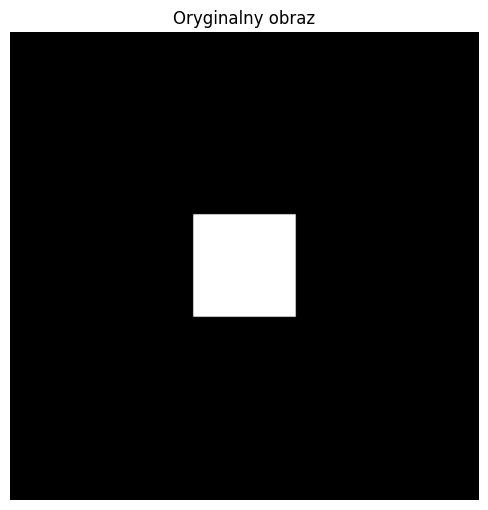

In [27]:
image = np.zeros((256, 256))
image[100:156, 100:156] = 255

fft_raw = np.fft.fft2(image)
fft_shifted = np.fft.fftshift(fft_raw)

var_raw_linear = np.abs(fft_raw)

#Bez Log, skala liniowa
var_shift_linear = np.abs(fft_shifted)

var_full = np.log(np.abs(fft_shifted) + 1)

plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.imshow(image, cmap='gray')
plt.title('Oryginalny obraz')
plt.axis('off')

plt.tight_layout()
plt.show()

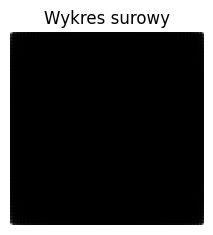

In [28]:
plt.subplot(2, 3, 2)

plt.imshow(var_raw_linear, cmap='gray')
plt.title('Wykres surowy')
plt.axis('off')

plt.tight_layout()
plt.show()

### Wykres przesunięty

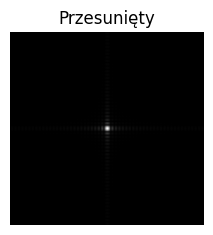

In [29]:
plt.subplot(2, 3, 3)
plt.imshow(var_shift_linear, cmap='gray')
plt.title('Przesunięty')
plt.axis('off')

plt.tight_layout()
plt.show()

Większość "energii" typowego obrazka (jego ogólna jasność i duże, gładkie płaszczyzny) skupia się w bardzo niskich częstotliwościach. To oznacza, że wartość środkowego piksela na wykresie widma bywa setki tysięcy, a nawet miliony razy większa niż wartości pikseli z wysokich częstotliwości (odpowiadających za drobne detale).

Monitor komputera wyświetla tylko 256 odcieni szarości. Jeśli przypiszemy ten gigantyczny piksel ze środka do czystej bieli (255), to wszystkie pozostałe piksele – ponieważ są od niego miliony razy mniejsze – zostaną bezlitośnie zaokrąglone do zera, czyli do czerni.

Funkcja logarytmiczna drastycznie zmniejsza gigantyczne wartości w centrum.
Jednocześnie relatywnie wzmacnia i wyciąga z cienia te malutkie wartości na brzegach.

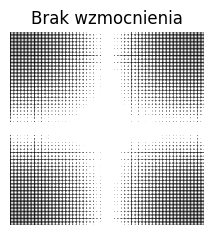

In [30]:
plt.subplot(2, 3, 5)
plt.imshow(var_shift_linear, cmap='gray', vmax=255)
plt.title('Brak wzmocnienia')
plt.axis('off')

plt.tight_layout()
plt.show()

### Dlaczego do wyniku logarytmu dodajemy 1
W widmie Fouriera może się zdarzyć, że wartość amplitudy wynosi dokładnie $0$. Oznacza to po prostu, że w obrazie nie ma danej częstotliwości przestrzennej. Z punktu widzenia matematyki funkcja logarytmiczna dla zera jest niezdefiniowana – dąży do minus nieskończoności.


Moduły (amplitudy) zwracane przez FFT mają gigantyczną rozpiętość. Częstotliwość zerowa (środek) może mieć wartość rzędu np. $1 000 000$, podczas gdy drobne detale zaledwie $5$ lub $10$.
Logarytm naturalny (funkcja np.log) drastycznie spłaszcza te wartości:

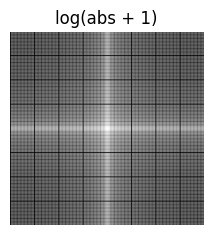

In [31]:
plt.subplot(2, 3, 6)
plt.imshow(var_full, cmap='gray')
plt.title('log(abs + 1)')
plt.axis('off')

plt.tight_layout()
plt.show()

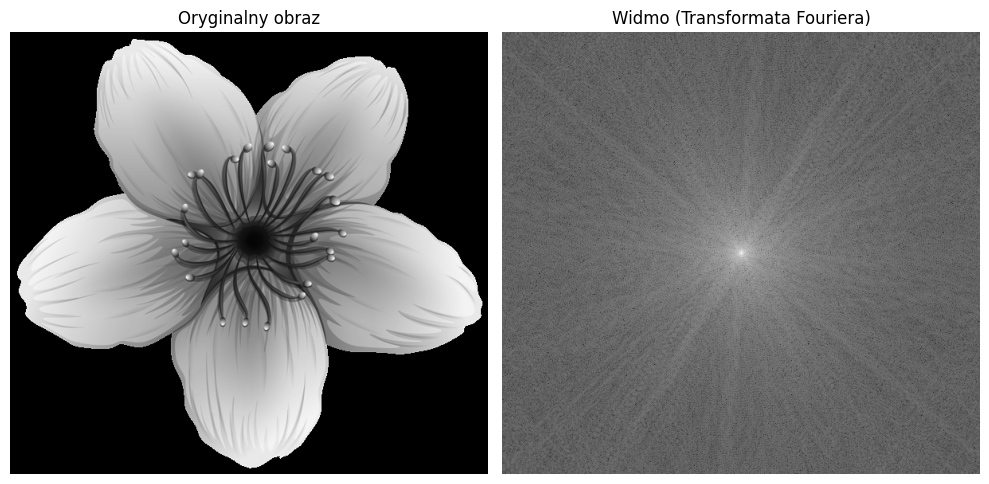

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def show_fourier_spectrum(image_path):

    img = Image.open(image_path).convert('L')
    img_array = np.array(img)

    f_transform = np.fft.fft2(img_array)

    f_shift = np.fft.fftshift(f_transform)

    magnitude_spectrum = np.log(np.abs(f_shift) + 1)

    plt.figure(figsize=(10, 5))

    plt.subplot(121)
    plt.imshow(img_array, cmap='gray')
    plt.title('Oryginalny obraz')
    plt.axis('off')

    plt.subplot(122)
    plt.imshow(magnitude_spectrum, cmap='gray')
    plt.title('Widmo (Transformata Fouriera)')
    plt.axis('off')

    plt.tight_layout()
    plt.show()
show_fourier_spectrum("flower.png")

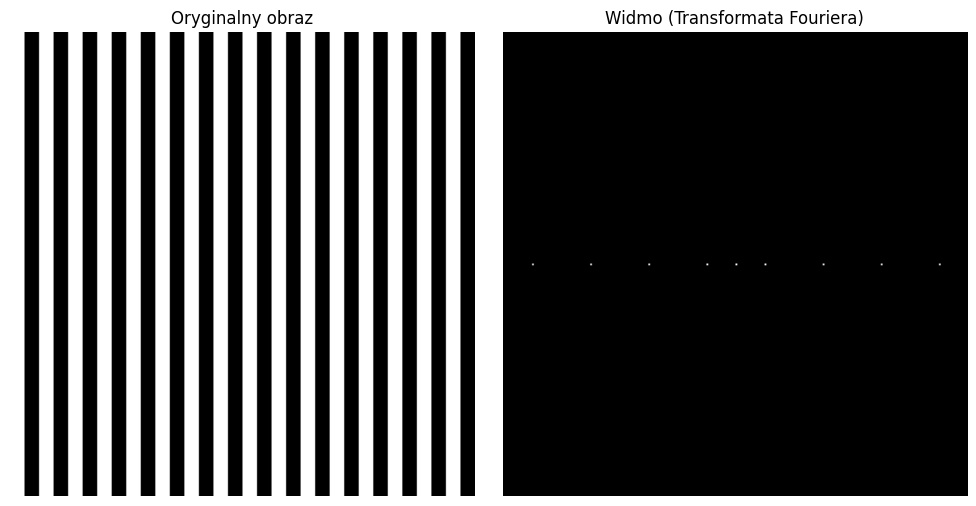

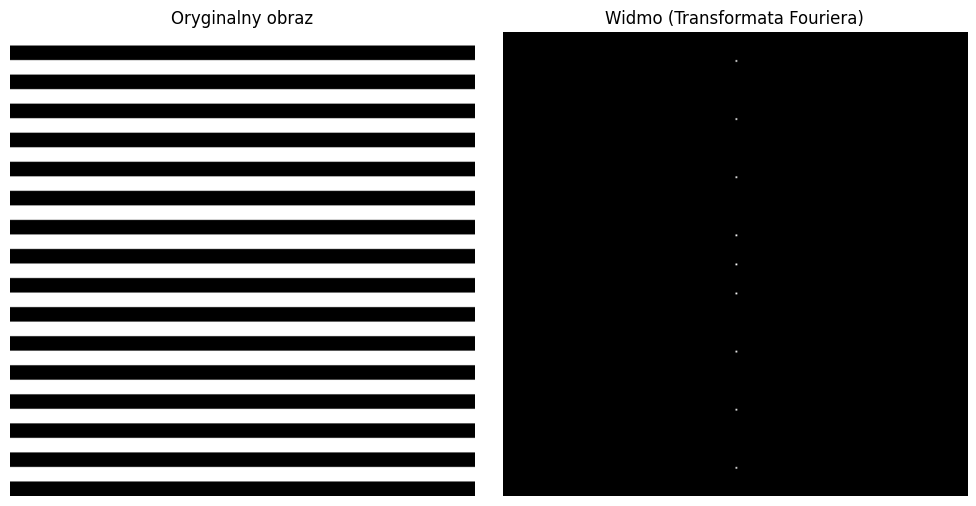

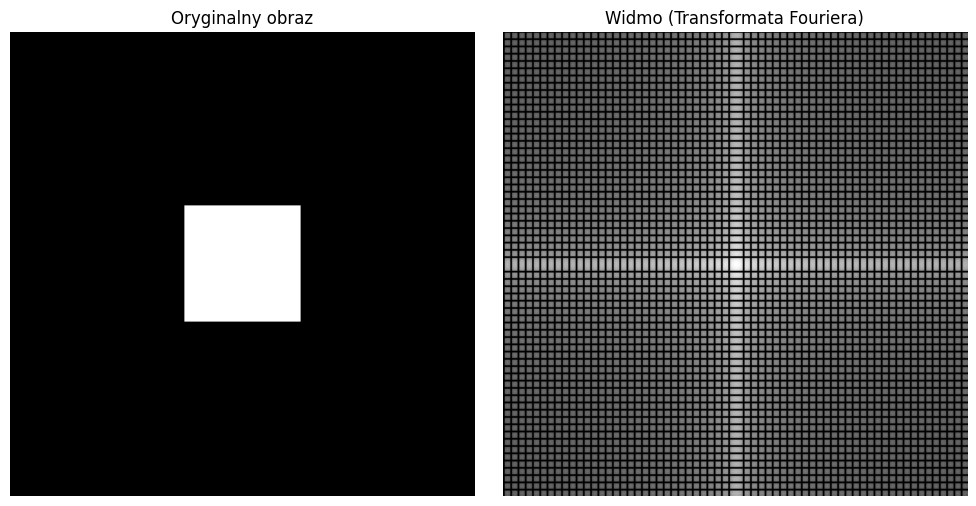

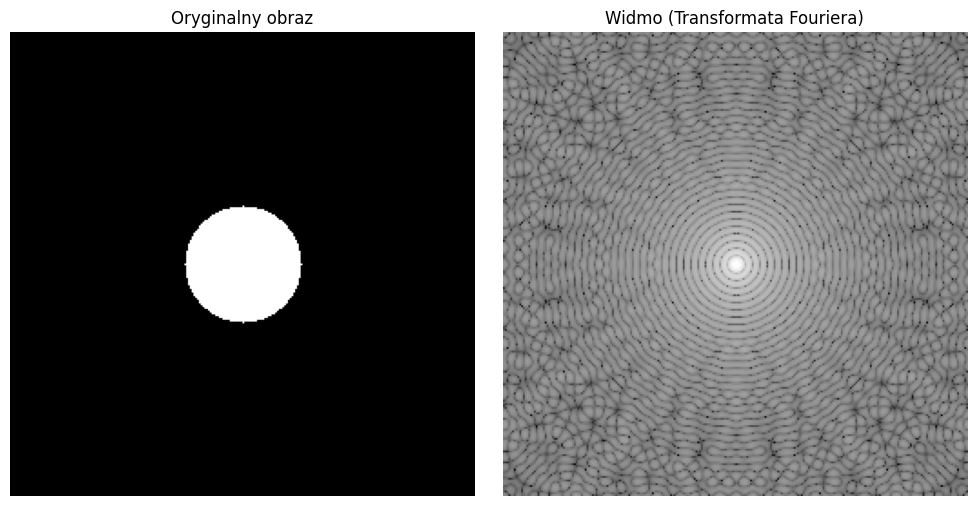

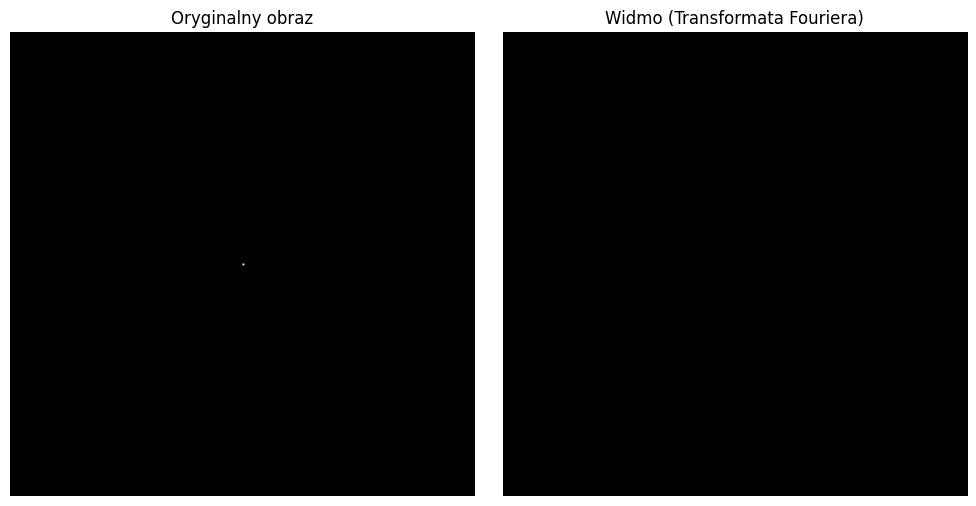

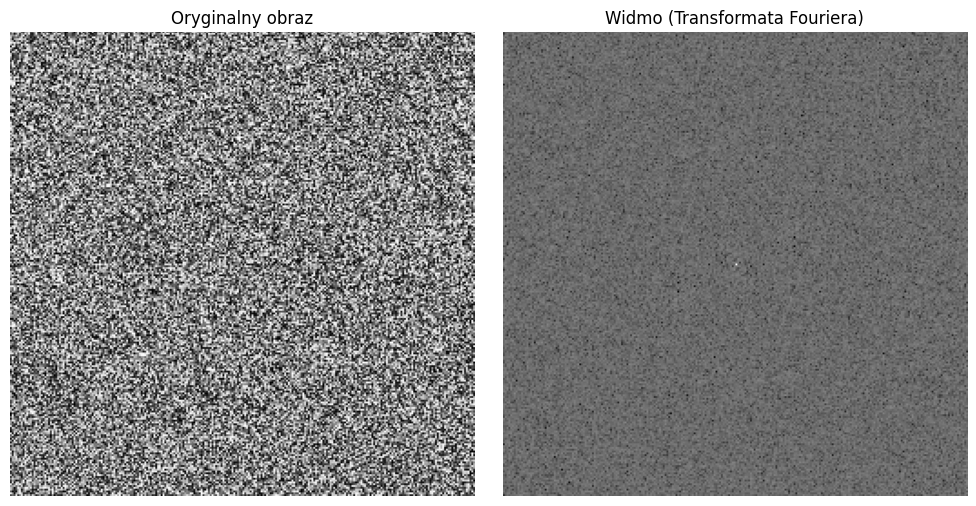

In [34]:
import os
test_cases = [
        ("test_1_pionowe.png", "Test 1: Paski Pionowe (Oczekujemy linii poziomej)"),
        ("test_2_poziome.png", "Test 2: Paski Poziome (Oczekujemy linii pionowej)"),
        ("test_3_kwadrat.png", "Test 3: Ostre narożniki (Kwadrat)"),
        ("test_4_kolo.png", "Test 4: Gładki kontur (Pierścienie Airy'ego)"),
        ("test_5_dirac.png", "Test 5: Impuls Diraca (Jeden piksel)"),
        ("test_6_szum.png",  "Test 6: Szum Losowy (Brak wzorców)")
    ]

for filename, title in test_cases:
    if os.path.exists(filename):
        show_fourier_spectrum(filename)
    else:
        print(f"Błąd: Nie znaleziono pliku {filename}")